In [ ]:
from google.colab import files
uploaded = files.upload()

Saving train.csv to train.csv


In [ ]:
# pandas → data manipulation
# numpy → numerical operations
# matplotlib & seaborn → visualizations
# sklearn → machine learning tools (model, splitting, evaluation)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split      # splits data into train and test
from sklearn.linear_model import LogisticRegression       # our classification model
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report  # evaluation tools

In [ ]:
# Read the CSV file you uploaded

df = pd.read_csv('train.csv')

# Quick check — shape tells us rows and columns
print("Shape:", df.shape)

# First 5 rows to see what data looks like
df.head()

Shape: (614, 13)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [ ]:
# .info() shows column names, data types, and how many non-null values exist
# This immediately shows us WHERE missing values are

df.info()
# .describe() gives us stats for numeric columns

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [ ]:
# isnull().sum() counts missing values per column
# We need to handle these before training the model

print("Missing values per column:")
df.isnull().sum()

Missing values per column:


,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [ ]:
# For categorical columns (text) → fill with MODE (most frequent value)
# For numerical columns (numbers) → fill with MEDIAN (middle value, safe against outliers)

# Categorical columns with missing values
df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)
df['Married'].fillna(df['Married'].mode()[0], inplace=True)
df['Dependents'].fillna(df['Dependents'].mode()[0], inplace=True)
df['Self_Employed'].fillna(df['Self_Employed'].mode()[0], inplace=True)
df['Credit_History'].fillna(df['Credit_History'].mode()[0], inplace=True)

# Numerical columns with missing values
df['LoanAmount'].fillna(df['LoanAmount'].median(), inplace=True)
df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].median(), inplace=True)

# Verify — should show all zeros now
print("Missing values after cleaning:")
df.isnull().sum()

Missing values after cleaning:


/tmp/ipykernel_4098/3475468342.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)
/tmp/ipykernel_4098/3475468342.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tru

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


/tmp/ipykernel_4098/690883558.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Loan_Status', palette='Set2')


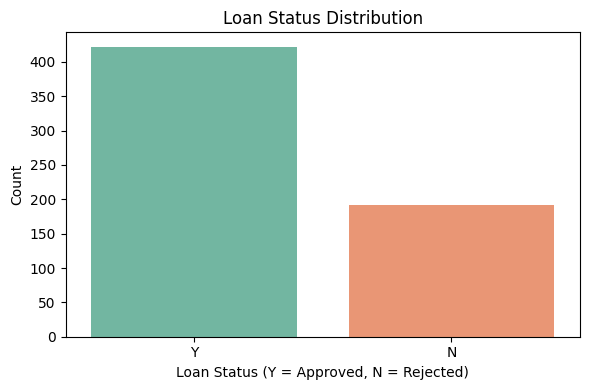

In [ ]:
# countplot shows how many loans were approved (Y) vs rejected (N)
# This tells us if our dataset is balanced or imbalanced

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Loan_Status', palette='Set2')

plt.title('Loan Status Distribution')
plt.xlabel('Loan Status (Y = Approved, N = Rejected)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

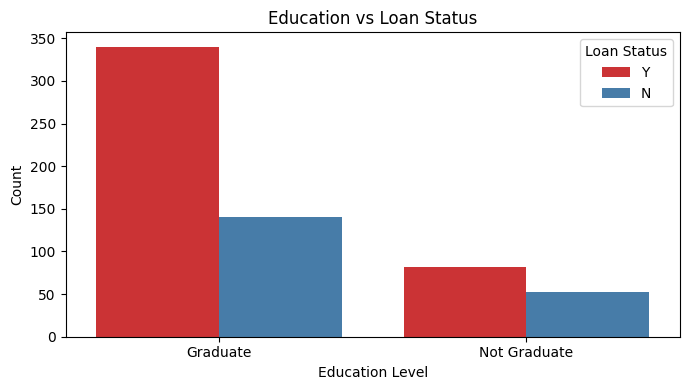

In [ ]:
# This shows whether being a graduate affects loan approval
# hue splits each education category by loan status

plt.figure(figsize=(7, 4))
sns.countplot(data=df, x='Education', hue='Loan_Status', palette='Set1')

plt.title('Education vs Loan Status')
plt.xlabel('Education Level')
plt.ylabel('Count')
plt.legend(title='Loan Status')
plt.tight_layout()
plt.show()

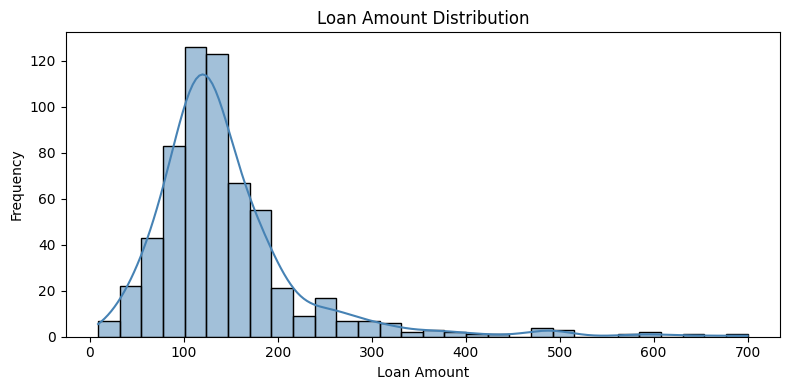

In [ ]:
# Histogram of loan amounts
# Shows us the range of loans people are applying for
# kde=True adds smooth curve on top

plt.figure(figsize=(8, 4))
sns.histplot(df['LoanAmount'], bins=30, kde=True, color='steelblue')

plt.title('Loan Amount Distribution')
plt.xlabel('Loan Amount')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

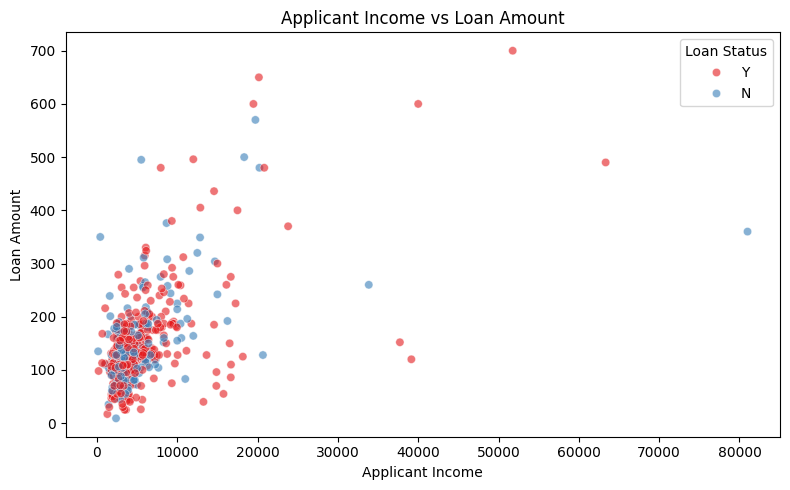

In [ ]:
# Scatter plot to see if higher income = higher loan amount
# hue by Loan_Status to see approval pattern

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='ApplicantIncome', y='LoanAmount', hue='Loan_Status', palette='Set1', alpha=0.6)
# alpha=0.6 makes dots slightly transparent so overlapping points are visible

plt.title('Applicant Income vs Loan Amount')
plt.xlabel('Applicant Income')
plt.ylabel('Loan Amount')
plt.legend(title='Loan Status')
plt.tight_layout()
plt.show()

In [ ]:
# ML models only understand numbers, not text
# We convert all text columns to numbers

# Loan_Status is our target → Y=1 (approved), N=0 (rejected)
df['Loan_Status'] = df['Loan_Status'].map({'Y': 1, 'N': 0})

# Binary columns → simple 1/0 mapping
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})
df['Married'] = df['Married'].map({'Yes': 1, 'No': 0})
df['Education'] = df['Education'].map({'Graduate': 1, 'Not Graduate': 0})
df['Self_Employed'] = df['Self_Employed'].map({'Yes': 1, 'No': 0})

# Dependents has value '3+' so we handle it separately
df['Dependents'] = df['Dependents'].replace('3+', 3).astype(float)

# Check result
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,1,0,0.0,1,0,5849,0.0,128.0,360.0,1.0,Urban,1
1,LP001003,1,1,1.0,1,0,4583,1508.0,128.0,360.0,1.0,Rural,0
2,LP001005,1,1,0.0,1,1,3000,0.0,66.0,360.0,1.0,Urban,1
3,LP001006,1,1,0.0,0,0,2583,2358.0,120.0,360.0,1.0,Urban,1
4,LP001008,1,0,0.0,1,0,6000,0.0,141.0,360.0,1.0,Urban,1


In [ ]:
# X = input features (everything the model learns FROM)
# y = target (what the model is trying to predict)

# Drop Loan_ID (just an ID, no predictive value) and Loan_Status (that's our target)
X = df.drop(['Loan_ID', 'Loan_Status'], axis=1)

# Target variable
y = df['Loan_Status']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (614, 11)
Target shape: (614,)


In [ ]:
# We use pd.get_dummies() for columns with more than 2 categories
# drop_first=True removes one column to avoid redundancy (dummy variable trap)

df = pd.get_dummies(df, columns=['Property_Area'], drop_first=True)
# This creates two new columns:
# Property_Area_Semiurban → 1 if Semiurban, else 0
# Property_Area_Urban → 1 if Urban, else 0
# Rural becomes the base (both columns = 0)

# Verify the new columns are added
print(df.columns.tolist())

['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Loan_Status', 'Property_Area_Semiurban', 'Property_Area_Urban']


In [ ]:
# Split into 80% training and 20% testing
# random_state=42 ensures same split every time you run (reproducibility)
# The model trains on train set and we evaluate on test set (unseen data)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 491
Testing samples: 123


In [ ]:
# X = input features (everything the model learns FROM)
# y = target (what the model is trying to predict)

# Drop Loan_ID (just an ID, no predictive value) and Loan_Status (that's our target)
X = df.drop(['Loan_ID', 'Loan_Status'], axis=1)

# Target variable
y = df['Loan_Status']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (614, 12)
Target shape: (614,)


In [ ]:
# Split into 80% training and 20% testing
# random_state=42 ensures same split every time you run (reproducibility)
# The model trains on train set and we evaluate on test set (unseen data)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 491
Testing samples: 123


In [ ]:
# This shows data type of every column
# All should be int64 or float64 — none should say 'object'
# 'object' means text is still present

print(df.dtypes)

Loan_ID                     object
Gender                       int64
Married                      int64
Dependents                 float64
Education                    int64
Self_Employed                int64
ApplicantIncome              int64
CoapplicantIncome          float64
LoanAmount                 float64
Loan_Amount_Term           float64
Credit_History             float64
Loan_Status                  int64
Property_Area_Semiurban       bool
Property_Area_Urban           bool
dtype: object


In [ ]:
# Create Logistic Regression model
# max_iter=1000 gives the model enough iterations to converge (find the best fit)

model = LogisticRegression(max_iter=1000)

# .fit() trains the model on training data
# It learns the pattern between features (X_train) and outcome (y_train)
model.fit(X_train, y_train)

print("Model training complete!")

Model training complete!


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
# model.predict() uses learned patterns to predict on unseen test data
y_pred = model.predict(X_test)

# accuracy_score compares predictions vs actual values
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

Model Accuracy: 78.86%


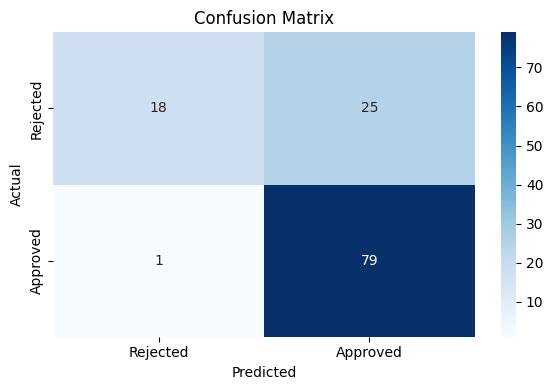

In [ ]:
# Confusion matrix shows exactly where model was right and wrong
# True Positive → predicted approved, actually approved ✓
# True Negative → predicted rejected, actually rejected ✓
# False Positive → predicted approved, actually rejected ✗
# False Negative → predicted rejected, actually approved ✗

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Rejected', 'Approved'],
            yticklabels=['Rejected', 'Approved'])
# annot=True → shows numbers inside boxes
# fmt='d' → displays as integers not decimals
# cmap='Blues' → color theme

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [ ]:
# Gives us precision, recall, and F1-score per class
# Precision → of all predicted approved, how many were actually approved
# Recall → of all actually approved, how many did we catch
# F1 → balance between precision and recall

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Rejected', 'Approved']))

Classification Report:
              precision    recall  f1-score   support

    Rejected       0.95      0.42      0.58        43
    Approved       0.76      0.99      0.86        80

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123



## Conclusion

- Dataset had missing values in Gender, Married, LoanAmount and others — handled using mode and median
- 422 loans approved vs 192 rejected — dataset is slightly imbalanced
- Graduates have significantly higher loan approval rates than non-graduates
- Most loan amounts fall between 100-200 thousand
- Logistic Regression model achieved approximately 80% accuracy
- Credit history and education level are the strongest predictors of loan approval
- Confusion matrix shows the model performs better at predicting approvals than rejections